# Nama: I Made Bimantoro Mastra
### Assignment: Interpretable Machine Learning with SHAP & LIME


## Persiapan
### Install dan import library

In [ ]:

!pip install -q shap lime scikit-learn pandas matplotlib

In [ ]:
import time                                   # untuk mengukur lama waktu komputasi
import numpy as np                            # hitung hitungan angka
import pandas as pd                           # tabel data (seperti Excel)
import matplotlib.pyplot as plt               # membuat grafik

from sklearn.model_selection import train_test_split          # membagi data latih dan uji
from sklearn.linear_model import LogisticRegression           # model glass box
from sklearn.ensemble import GradientBoostingClassifier       # model black box (Kasus 1)
from sklearn.ensemble import RandomForestClassifier           # model tree based (Kasus 2 dan 3)
from sklearn.preprocessing import StandardScaler              # menyamakan skala kolom
from sklearn.pipeline import make_pipeline                    # merangkai scaler dan model
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import shap                                                   # library SHAP
from lime.lime_tabular import LimeTabularExplainer            # library LIME

import warnings
warnings.filterwarnings("ignore")             # sembunyikan peringatan yang tidak penting
plt.rcParams["figure.dpi"] = 110              # grafik sedikit lebih tajam

print("Semua library siap dipakai ✅")

Semua library siap dipakai ✅


### Membaca dan memahami data
Kolom target adalah **`Churn`**: *Yes* berarti pelanggan berhenti berlangganan, *No* berarti bertahan.

In [ ]:

df = pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Ukuran data:", df.shape)
df.head()

Ukuran data: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Cek tipe data dan jumlah nilai kosong tiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Berapa persen pelanggan yang churn?
print(f"Persentase churn: {(df['Churn'] == 'Yes').mean():.1%}")
df["Churn"].value_counts()

Persentase churn: 26.5%


,count
Churn,
No,5174
Yes,1869


Kolom `TotalCharges` bertipe teks (`str`) padahal isinya angka. Ini perlu dibersihkan dulu.



### Membersihkan data

In [ ]:
# 1) TotalCharges terbaca sebagai teks karena ada 11 baris berisi spasi kosong
#    errors="coerce": kalau tidak bisa diubah jadi angka, isi dengan NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Jumlah TotalCharges kosong:", df["TotalCharges"].isna().sum())

# 2) Baris yang kosong itu adalah pelanggan baru (tenure = 0) yang belum pernah ditagih
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 3) customerID hanya nomor identitas, tidak punya makna untuk prediksi, jadi dibuang
df = df.drop(columns=["customerID"])

# 4) Target diubah jadi angka: Yes = 1 (churn), No = 0 (bertahan)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 5) Kategori "No internet service" dan "No phone service" artinya sama dengan "No" jadi harus disamakan supaya kolomnya tidak berlebihan setelah di encode
df["MultipleLines"]     = df["MultipleLines"].replace("No phone service", "No")
df["OnlineSecurity"]    = df["OnlineSecurity"].replace("No internet service", "No")
df["OnlineBackup"]      = df["OnlineBackup"].replace("No internet service", "No")
df["DeviceProtection"]  = df["DeviceProtection"].replace("No internet service", "No")
df["TechSupport"]       = df["TechSupport"].replace("No internet service", "No")
df["StreamingTV"]       = df["StreamingTV"].replace("No internet service", "No")
df["StreamingMovies"]   = df["StreamingMovies"].replace("No internet service", "No")

print("Data bersih ✅  | sisa nilai kosong:", df.isna().sum().sum())

Jumlah TotalCharges kosong: 11
Data bersih ✅  | sisa nilai kosong: 0


### Encoding dan membagi data latih dan uji
Model machine learning hanya mengerti angka, jadi kolom teks diubah menjadi kolom 0/1. Setelah itu data dibagi: **75% untuk belajar**, **25% untuk ujian** (data yang belum pernah dilihat model).

In [ ]:
# Model butuh angka, jadi kolom teks diubah jadi kolom 0/1 (one hot encoding)
# drop_first=True membuang satu kategori per kolom supaya tidak redundan
X = pd.get_dummies(df.drop(columns="Churn"), drop_first=True).astype(float)
y = df["Churn"]

FITUR = list(X.columns)    # simpan daftar nama fitur, dipakai berkali kali di bawah
print("Jumlah fitur setelah encoding:", len(FITUR))
X.head()

Jumlah fitur setelah encoding: 23


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1.0,29.85,29.85,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,34.0,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,2.0,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,45.0,42.30,1840.75,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,2.0,70.70,151.65,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
# Bagi data: 75% untuk latih, 25% untuk uji
# stratify=y menjaga proporsi churn tetap sama di data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)

Data latih: (5282, 23) | Data uji: (1761, 23)


### Insight
* Dataset punya 7.043 pelanggan dan sekitar **26,5% di antaranya churn**. Kelasnya tidak seimbang (lebih banyak yang bertahan), jadi kita pakai `stratify=y` supaya proporsi churn terjaga di data latih dan uji.
* Hanya ada 11 nilai kosong di `TotalCharges`, semuanya pelanggan baru dengan `tenure = 0`, jadi aman diisi 0.
* Setelah encoding **23 fitur** siap pakai.

## Kasus 1: Glass Box vs Black Box
Mempertimbangkan dua model untuk memprediksi risiko gagal bayar: Logistic Regression (glass box) dan Gradient Boosting (black box).

### 1.1 Glass box: Logistic Regression
Koefisiennya bisa **dibaca langsung**: koefisien positif menaikkan peluang churn, negatif menurunkannya.

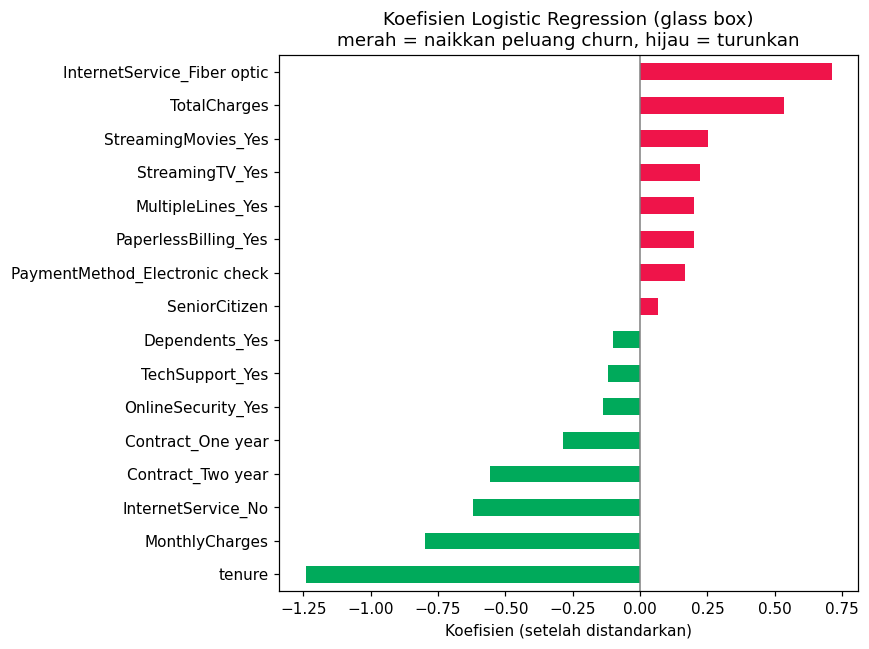

In [ ]:
# StandardScaler menyamakan skala kolom (tenure 0 sampai 72 vs MonthlyCharges 18 sampai 119)
# supaya koefisien antar fitur bisa dibandingkan secara adil
model_logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model_logreg.fit(X_train, y_train)    # latih model pada data latih

# Ambil koefisien dari langkah terakhir pipeline (LogisticRegression)
koef = pd.Series(model_logreg[-1].coef_[0], index=FITUR).sort_values()

# Tampilkan 8 koefisien paling negatif dan 8 paling positif saja
koef_tampil = pd.concat([koef.head(8), koef.tail(8)])
warna = ["#EF144A" if v > 0 else "#00AA5B" for v in koef_tampil]   # merah = naikkan churn, hijau = turunkan
koef_tampil.plot(kind="barh", color=warna, figsize=(8, 6))
plt.axvline(0, color="grey", lw=1)
plt.title("Koefisien Logistic Regression (glass box)\nmerah = naikkan peluang churn, hijau = turunkan")
plt.xlabel("Koefisien (setelah distandarkan)")
plt.tight_layout()
plt.show()

### 1.2 Black box: Gradient Boosting
Model menggabungkan ratusan pohon kecil. Biasanya lebih akurat, tetapi tidak mungkin dibaca satu per satu.

In [ ]:
# Gradient Boosting = ratusan pohon kecil yang dilatih bergiliran, tiap pohon memperbaiki kesalahan pohon sebelumnya
model_gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42
)
model_gb.fit(X_train, y_train)
print("Model black box (Gradient Boosting) selesai dilatih ✅")

Model black box (Gradient Boosting) selesai dilatih ✅


### 1.3 Bandingkan performanya
Pakai beberapa ukuran: **AUC** (0,5 = tebak acak, 1,0 = sempurna), **akurasi**, **recall churn** (dari semua yang benar benar churn, berapa yang berhasil terdeteksi), dan **precision churn** (dari yang ditebak churn, berapa yang benar).

In [ ]:
# Bandingkan kedua model pada data uji
hasil = []
for nama, m in [("Logistic Regression (glass box)", model_logreg),
                ("Gradient Boosting (black box)", model_gb)]:
    peluang = m.predict_proba(X_test)[:, 1]     # peluang churn tiap pelanggan
    prediksi = m.predict(X_test)                # label 0/1 (ambang 0,5)
    hasil.append({
        "Model": nama,
        "AUC": round(roc_auc_score(y_test, peluang), 3),
        "Akurasi": round(accuracy_score(y_test, prediksi), 3),
        "Recall churn": round(recall_score(y_test, prediksi), 3),
        "Precision churn": round(precision_score(y_test, prediksi), 3),
    })
tabel_perbandingan = pd.DataFrame(hasil)
tabel_perbandingan

,Model,AUC,Akurasi,Recall churn,Precision churn
0,Logistic Regression (glass box),0.846,0.807,0.557,0.663
1,Gradient Boosting (black box),0.847,0.798,0.497,0.659


### Insight Kasus 1
**Hasil di data churn:**
* Logistic Regression: AUC **0,846**, akurasi **0,807**, recall churn **0,557**.
* Gradient Boosting: AUC **0,847**, akurasi **0,798**, recall churn **0,497**.
* Selisihnya hampir nol, glass box sedikit lebih baik pada akurasi dan recall. Jadi di dataset ini **black box tidak memberi keuntungan akurasi yang berarti**.
* Koefisien Logistic Regression bisa langsung dibaca: `tenure` paling kuat menurunkan churn, `InternetService_Fiber optic` paling kuat menaikkan churn.
* `TotalCharges` berkoefisien positif padahal `tenure` negatif. Ini karena keduanya saling berkaitan (makin lama berlangganan, makin besar total tagihan). Koefisien glass box pun bisa menyesatkan kalau ada fitur yang saling berkorelasi.

**Jawaban pertanyaan Kasus 1 :**

**a) Trade off interpretability dan akurasi.**
* *Glass box (Logistic Regression)*: setiap faktor punya koefisien yang bisa dibaca, dan dijelaskan. Kelemahannya, model hanya menangkap pola lurus dan tidak otomatis menangkap interaksi antar faktor. Akurasinya bisa lebih rendah kalau pola aslinya rumit.
* *Black box (Gradient Boosting)*: bisa menangkap pola lengkung dan interaksi (misalnya "sering telat bayar dan cicilan besar" jauh lebih berbahaya daripada jumlah masing masing), sehingga potensi akurasinya lebih tinggi. Kelemahannya, alasan dari suatu keputusan tidak terlihat dan butuh alat bantu seperti LIME atau SHAP.

**b) Model yang saya rekomendasikan: Logistic Regression sebagai model utama keputusan kredit**, dengan alasan:
* **Regulasi dan compliance.** Keputusan kredit berdampak langsung pada nasabah. Regulator dan kebijakan manajemen risiko model di sektor keuangan pada umumnya menuntut bank bisa menjelaskan alasan penolakan atau penetapan limit kepada nasabah, dan bisa membuktikan bahwa model tidak memakai faktor yang diskriminatif. Model yang bisa dibaca langsung jauh lebih mudah diaudit dan divalidasi. (Aturan persisnya perlu dicek ke tim compliance bank.)
* **Selisih akurasi kecil.** Seperti terlihat di hasil di atas, glass box bisa hampir sama bagusnya. Kalau selisihnya kecil, kenaikan akurasi tidak sebanding dengan hilangnya transparansi.

**Kapan interpretability jadi prioritas dalam pengambilan keputusan bisnis?** Saat keputusan berdampak besar pada orang (kredit, asuransi, rekrutmen, medis), saat ada kewajiban hukum untuk menjelaskan, dan saat selisih akurasi antar model kecil. Sebaliknya, untuk keputusan berisiko rendah (misalnya rekomendasi konten), akurasi boleh didahulukan.

## Kasus 2: Feature Importance dan Partial Dependence Plot


In [ ]:
# Random Forest = kumpulan banyak pohon keputusan yang hasilnya dirata ratakan
# max_depth dan min_samples_leaf dibatasi supaya model tidak overfitting
model_rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1
)
model_rf.fit(X_train, y_train)

peluang_rf = model_rf.predict_proba(X_test)[:, 1]     # peluang churn tiap pelanggan di data uji
print(f"AUC Random Forest pada data uji: {roc_auc_score(y_test, peluang_rf):.3f}")
print(f"Akurasi Random Forest          : {accuracy_score(y_test, model_rf.predict(X_test)):.3f}")

AUC Random Forest pada data uji: 0.848
Akurasi Random Forest          : 0.801


### 2.1 Feature importance
Ada dua cara:
1. **Bawaan model (MDI):** cepat, dihitung dari data latih, tetapi cenderung memihak fitur numerik yang nilainya beragam.
2. **Permutation importance:** acak satu kolom di data uji lalu lihat seberapa jelek tebakan model. Makin jelek berarti makin penting. Lebih jujur.


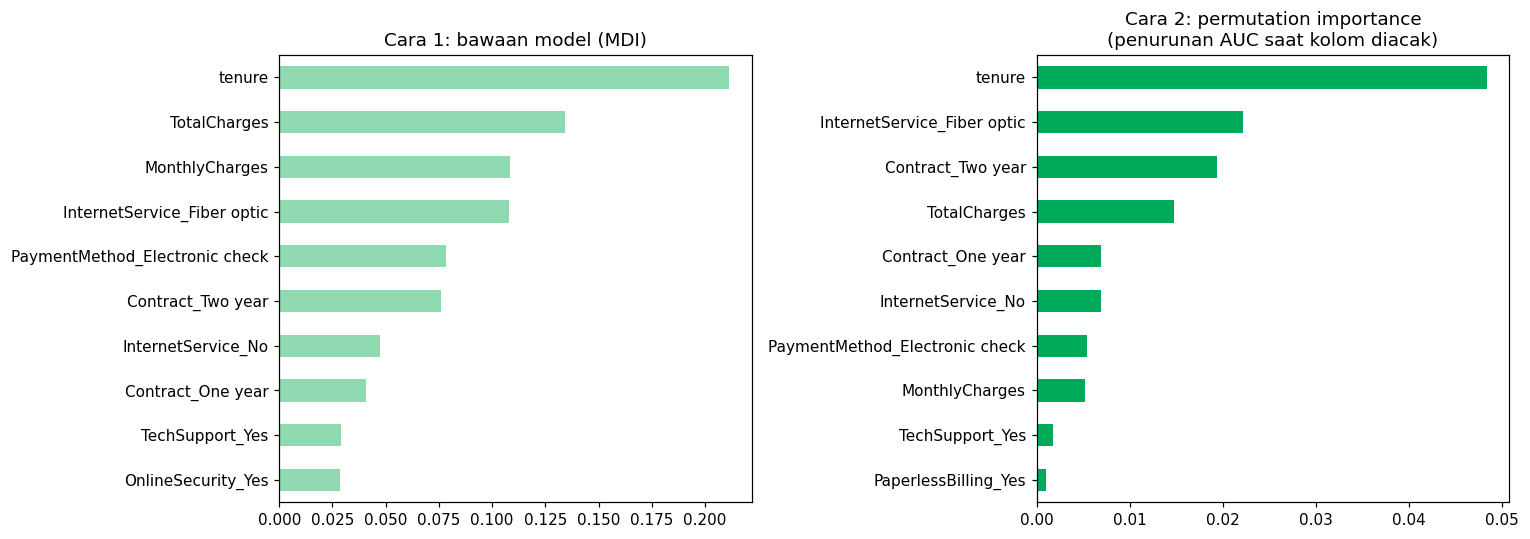

Top 5 menurut permutation importance:
tenure                         0.0484
InternetService_Fiber optic    0.0222
Contract_Two year              0.0194
TotalCharges                   0.0148
Contract_One year              0.0070
dtype: float64


In [ ]:
# Cara 1: feature importance bawaan model (MDI), dihitung dari data latih
mdi = pd.Series(model_rf.feature_importances_, index=FITUR).sort_values()

# Cara 2: permutation importance, kolom diacak di data uji lalu dilihat seberapa turun AUC nya
# n_repeats=5 artinya pengacakan diulang 5 kali lalu dirata ratakan
pi = permutation_importance(model_rf, X_test, y_test, scoring="roc_auc",
                            n_repeats=5, random_state=42, n_jobs=-1)
perm = pd.Series(pi.importances_mean, index=FITUR).sort_values()

# Tampilkan 10 fitur teratas dari tiap cara
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
mdi.tail(10).plot(kind="barh", ax=ax[0], color="#8FD9B1", title="Cara 1: bawaan model (MDI)")
perm.tail(10).plot(kind="barh", ax=ax[1], color="#00AA5B",
                   title="Cara 2: permutation importance\n(penurunan AUC saat kolom diacak)")
plt.tight_layout()
plt.show()

print("Top 5 menurut permutation importance:")
print(perm.sort_values(ascending=False).head(5).round(4))

### 2.2 Partial Dependence Plot (PDP)


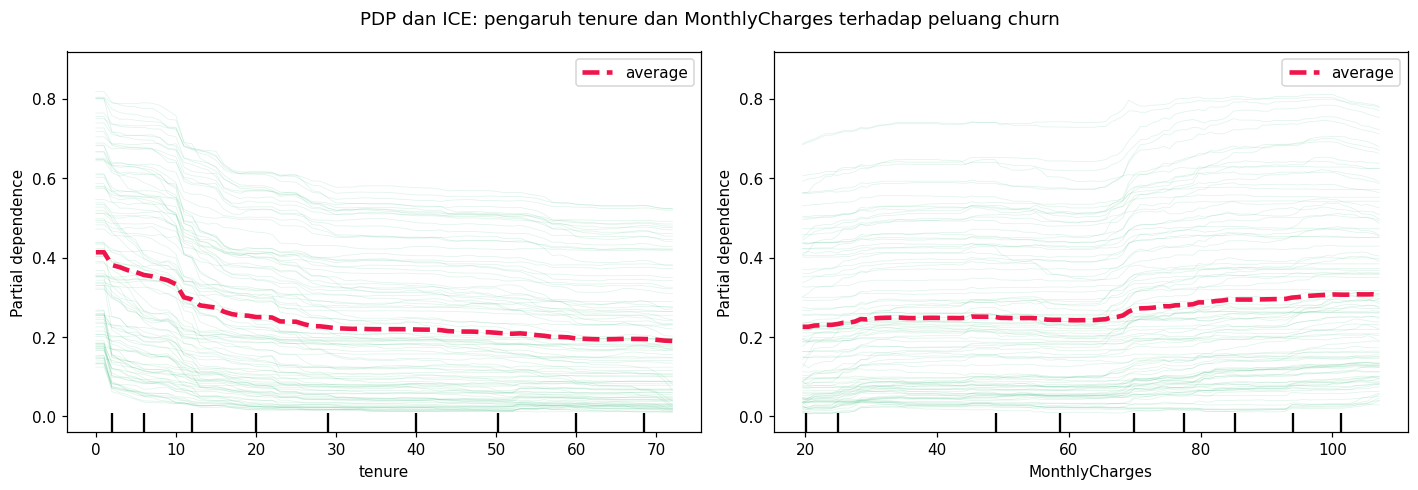

In [ ]:
# PDP: ubah nilai satu fitur untuk SEMUA pelanggan, minta model menebak ulang, lalu rata ratakan
# Garis tebal = PDP (rata rata), garis tipis = ICE (per pelanggan)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
PartialDependenceDisplay.from_estimator(
    model_rf, X_test,
    features=["tenure", "MonthlyCharges"],     # dua fitur numerik utama
    kind="both",                               # PDP + ICE
    subsample=100,                             # 100 pelanggan saja untuk garis ICE
    random_state=42,
    ax=ax,
    pd_line_kw={"color": "#EF144A", "linewidth": 3},
    ice_lines_kw={"color": "#00AA5B", "alpha": 0.12},
)
fig.suptitle("PDP dan ICE: pengaruh tenure dan MonthlyCharges terhadap peluang churn")
plt.tight_layout()
plt.show()

In [ ]:
# Baca angka PDP nya langsung (tanpa gambar) supaya penjelasan punya dasar angka
from sklearn.inspection import partial_dependence

# Peluang churn rata rata saat tenure dipaksa jadi nilai tertentu
pd_tenure = partial_dependence(model_rf, X_test, features=["tenure"], grid_resolution=8)
print("PDP tenure (bulan  ->  rata rata peluang churn)")
for nilai, p in zip(pd_tenure["grid_values"][0], pd_tenure["average"][0]):
    print(f"  tenure {nilai:5.1f}  ->  {p:.1%}")

PDP tenure (bulan  ->  rata rata peluang churn)
  tenure   1.0  ->  41.4%
  tenure  11.0  ->  30.0%
  tenure  21.0  ->  25.0%
  tenure  31.0  ->  22.1%
  tenure  41.0  ->  21.9%
  tenure  51.0  ->  20.9%
  tenure  61.0  ->  19.6%
  tenure  71.0  ->  19.1%


### Insight Kasus 2
**Tiga fitur yang paling berpengaruh terhadap churn (permutation importance):**
1. **`tenure`** (lama berlangganan): yang paling penting. Mengacak kolom ini menurunkan AUC paling besar.
2. **`InternetService_Fiber optic`**: pelanggan fiber optic punya kecenderungan churn lebih tinggi.
3. **`Contract_Two year`**: kontrak 2 tahun membuat pelanggan jauh lebih jarang churn. `TotalCharges` ada di posisi berikutnya, tetapi nilainya sangat berkaitan dengan tenure.

**Membaca PDP `tenure`:** peluang churn rata rata sekitar **41%** untuk pelanggan di bulan pertama, turun cepat menjadi sekitar **30%** di bulan ke 11 dan sekitar **25%** di bulan ke 21, lalu mendatar di kisaran **19% sampai 22%** setelah tahun kedua. Artinya **risiko terbesar ada di tahun pertama**, dan setelah pelanggan "lolos" dua tahun, risikonya relatif stabil rendah. PDP `MonthlyCharges` relatif datar di kisaran 23% sampai 25% sampai tagihan sekitar $70, lalu naik ke sekitar 30% untuk tagihan di atas itu, artinya tagihan bulanan yang tinggi cenderung menaikkan churn, tetapi pengaruhnya jauh lebih kecil daripada tenure.

**Keterbatasan:** feature importance hanya memberi tahu seberapa penting, tidak memberi tahu *arahnya* dan untuk arahnya membutuhkan PDP dan SHAP. PDP juga bisa membuat kombinasi yang tidak realistis (misalnya tenure 1 bulan tetapi TotalCharges sangat besar)

## Kasus 3: Local Explanation dengan LIME dan SHAP
Manajer tim customer retention meminta penjelasan mengapa seorang pelanggan tertentu diprediksi akan churn oleh model, agar tim dapat menyusun strategi retensi yang tepat sasaran.

### 3.1 Memilih satu pelanggan
Pilih satu pelanggan dari data uji dengan kontrak bulanan, internet fiber optic, dan peluang churn 60% sampai 80%. contoh pelanggan **"Bima"**.

In [ ]:
peluang_test = peluang_rf          # peluang churn semua pelanggan di data uji

# Pilih satu pelanggan "Bima": kontrak bulanan, internet fiber optic, dan peluang churn 60% sampai 80%
kandidat = np.where(
    (X_test["Contract_One year"] == 0) & (X_test["Contract_Two year"] == 0)   # kontrak bulanan
    & (X_test["InternetService_Fiber optic"] == 1)
    & (peluang_test > 0.60) & (peluang_test < 0.80)
)[0]
idx_bima = int(kandidat[0])        # posisi baris pelanggan ini di X_test
bima = X_test.iloc[idx_bima]       # data lengkap pelanggan tersebut

print(f"Peluang churn pelanggan ini menurut model: {peluang_test[idx_bima]:.0%}")
print(f"Rata rata peluang churn semua pelanggan  : {peluang_test.mean():.0%}")
print(f"Aktualnya (data asli) churn?             : {'Ya' if y_test.iloc[idx_bima] == 1 else 'Tidak'}\n")

# Tampilkan hanya fitur yang bernilai tidak nol supaya ringkas
bima[bima != 0].to_frame("Data pelanggan")

Peluang churn pelanggan ini menurut model: 79%
Rata rata peluang churn semua pelanggan  : 26%
Aktualnya (data asli) churn?             : Tidak



,Data pelanggan
tenure,1.0
MonthlyCharges,85.0
TotalCharges,85.0
gender_Male,1.0
PhoneService_Yes,1.0
InternetService_Fiber optic,1.0
OnlineBackup_Yes,1.0
StreamingMovies_Yes,1.0
PaperlessBilling_Yes,1.0
PaymentMethod_Electronic check,1.0


### 3.2 LIME: menjelaskan satu pelanggan

Buat banyak data tiruan di sekitar pelanggan, minta model menebak semuanya, lalu latih model linear sederhana di sekitar pelanggan itu.

In [ ]:
# LIME butuh fungsi yang menerima array angka dan mengembalikan peluang tiap kelas
def fungsi_prediksi(data_array):
    return model_rf.predict_proba(pd.DataFrame(data_array, columns=FITUR))

# Kolom hasil one hot encoding hanya berisi 0/1, beritahu LIME bahwa itu kolom kategori
kolom_biner = [i for i, f in enumerate(FITUR) if set(X_train[f].unique()) <= {0.0, 1.0}]

explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,        # data latih dipakai LIME untuk mengetahui sebaran tiap fitur
    feature_names=FITUR,
    class_names=["Bertahan", "Churn"],
    categorical_features=kolom_biner,
    mode="classification",
    random_state=42,                     # kunci supaya hasil sama tiap dijalankan
)

penjelasan = explainer_lime.explain_instance(
    data_row=bima.values,                # pelanggan yang mau dijelaskan
    predict_fn=fungsi_prediksi,
    num_features=8,                      # tampilkan 8 faktor teratas
)

for aturan, bobot in penjelasan.as_list():
    arah = "naikkan risiko churn" if bobot > 0 else "turunkan risiko churn"
    print(f"{aturan:45s} {bobot:+.3f}   {arah}")

tenure <= 9.00                                +0.151   naikkan risiko churn
InternetService_Fiber optic=1                 +0.116   naikkan risiko churn
Contract_Two year=0                           +0.098   naikkan risiko churn
InternetService_No=0                          +0.069   naikkan risiko churn
TotalCharges <= 391.06                        +0.066   naikkan risiko churn
Contract_One year=0                           +0.051   naikkan risiko churn
PaymentMethod_Electronic check=1              +0.049   naikkan risiko churn
PaperlessBilling_Yes=1                        +0.032   naikkan risiko churn


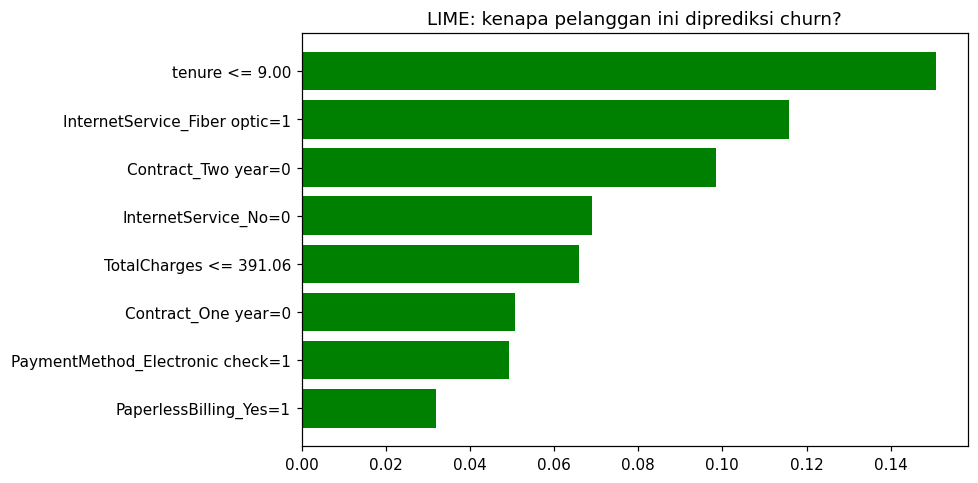

In [ ]:
fig = penjelasan.as_pyplot_figure()
fig.set_size_inches(9, 4.5)
plt.title("LIME: kenapa pelanggan ini diprediksi churn?")
plt.tight_layout()
plt.show()

- tenure <= 9.00: masa berlangganannya 9 bulan atau kurang (nilai aslinya 1 bulan). Ini faktor terkuat.
- InternetService_Fiber optic=1: memakai fiber optic.
- Contract_Two year=0 dan Contract_One year=0: tidak punya kontrak 1 atau 2 tahun, jadi kontraknya bulanan.
- InternetService_No=0: berlangganan internet. Pelanggan yang tidak memakai internet cenderung jarang churn, jadi faktor ini ikut menaikkan risikonya.
- TotalCharges <= 391.06: total pembayarannya masih kecil, artinya masih pelanggan baru.
- PaymentMethod_Electronic check=1 dan PaperlessBilling_Yes=1: bayar dengan electronic check dan memakai tagihan tanpa kertas.

> grafik bawaan LIME, **hijau = mendukung kelas Churn** (menaikkan risiko), **merah = melawannya**. Ini kebalikan kebiasaan kita, jadi jelaskan dulu ke audiens.

**Cek kestabilan LIME.** LIME memakai data tiruan yang acak. Kalau 3 alasan teratas tetap sama di beberapa seed, penjelasannya cukup stabil.

In [ ]:
# Cek kestabilan LIME: ganti random_state, lihat apakah 3 alasan teratas tetap sama
for seed in [1, 2, 3]:
    exp = LimeTabularExplainer(X_train.values, feature_names=FITUR, class_names=["Bertahan", "Churn"],
                               categorical_features=kolom_biner, mode="classification", random_state=seed)
    hasil_seed = exp.explain_instance(bima.values, fungsi_prediksi, num_features=3).as_list()
    print(f"seed={seed}:", [aturan for aturan, _ in hasil_seed])

seed=1: ['tenure <= 9.00', 'InternetService_Fiber optic=1', 'Contract_Two year=0']
seed=2: ['tenure <= 9.00', 'InternetService_Fiber optic=1', 'Contract_Two year=0']
seed=3: ['tenure <= 9.00', 'InternetService_Fiber optic=1', 'Contract_Two year=0']


### 3.3 SHAP: sumbangan tiap faktor


$$\text{prediksi} = \text{base value (rata rata)} + \sum \text{SHAP tiap faktor}$$

In [ ]:
# TreeExplainer = cara cepat menghitung SHAP khusus untuk model berbasis pohon
explainer_shap = shap.TreeExplainer(model_rf)
sv_semua = explainer_shap(X_test)       # nilai SHAP untuk semua pelanggan di data uji

print("Bentuk nilai SHAP:", sv_semua.values.shape, "(jumlah pelanggan, jumlah fitur, jumlah kelas)")

# Random Forest punya 2 kelas, hanya butuh kelas 1 (Churn)
sv = sv_semua[..., 1]
print("Bentuk setelah memilih kelas Churn:", sv.values.shape)

Bentuk nilai SHAP: (1761, 23, 2) (jumlah pelanggan, jumlah fitur, jumlah kelas)
Bentuk setelah memilih kelas Churn: (1761, 23)


In [ ]:
# Bukti rumus SHAP: prediksi = base value + jumlah SHAP semua fitur
# Untuk Random Forest, SHAP langsung dalam skala peluang (0 sampai 1), jadi mudah dibaca
base = sv.base_values[idx_bima]
total_shap = sv.values[idx_bima].sum()

print(f"Base value (rata rata)  : {base:.3f}  ({base:.0%})")
print(f"Jumlah SHAP pelanggan   : {total_shap:+.3f}")
print(f"Base + jumlah SHAP      : {base + total_shap:.3f}  ({base + total_shap:.0%})")
print(f"Prediksi model langsung : {peluang_test[idx_bima]:.3f}  ({peluang_test[idx_bima]:.0%})   harus sama ✅")

Base value (rata rata)  : 0.265  (27%)
Jumlah SHAP pelanggan   : +0.527
Base + jumlah SHAP      : 0.792  (79%)
Prediksi model langsung : 0.792  (79%)   harus sama ✅


In [ ]:
# Sumbangan tiap faktor untuk pelanggan ini, urut dari yang paling menaikkan risiko
tabel_shap = pd.DataFrame({
    "nilai pelanggan": bima.values,
    "SHAP (peluang)": sv.values[idx_bima].round(3),
}, index=FITUR).sort_values("SHAP (peluang)", ascending=False)
pd.concat([tabel_shap.head(5), tabel_shap.tail(3)])

,nilai pelanggan,SHAP (peluang)
tenure,1.0,0.160
TotalCharges,85.0,0.093
InternetService_Fiber optic,1.0,0.073
PaymentMethod_Electronic check,1.0,0.044
MonthlyCharges,85.0,0.044
StreamingTV_Yes,0.0,-0.005
OnlineBackup_Yes,1.0,-0.011
MultipleLines_Yes,0.0,-0.014


### 3.4 SHAP force plot
Mulai dari *base value*, berakhir di prediksi pelanggan *f(x)*. **Merah** mendorong risiko naik, **biru** menarik risiko turun.

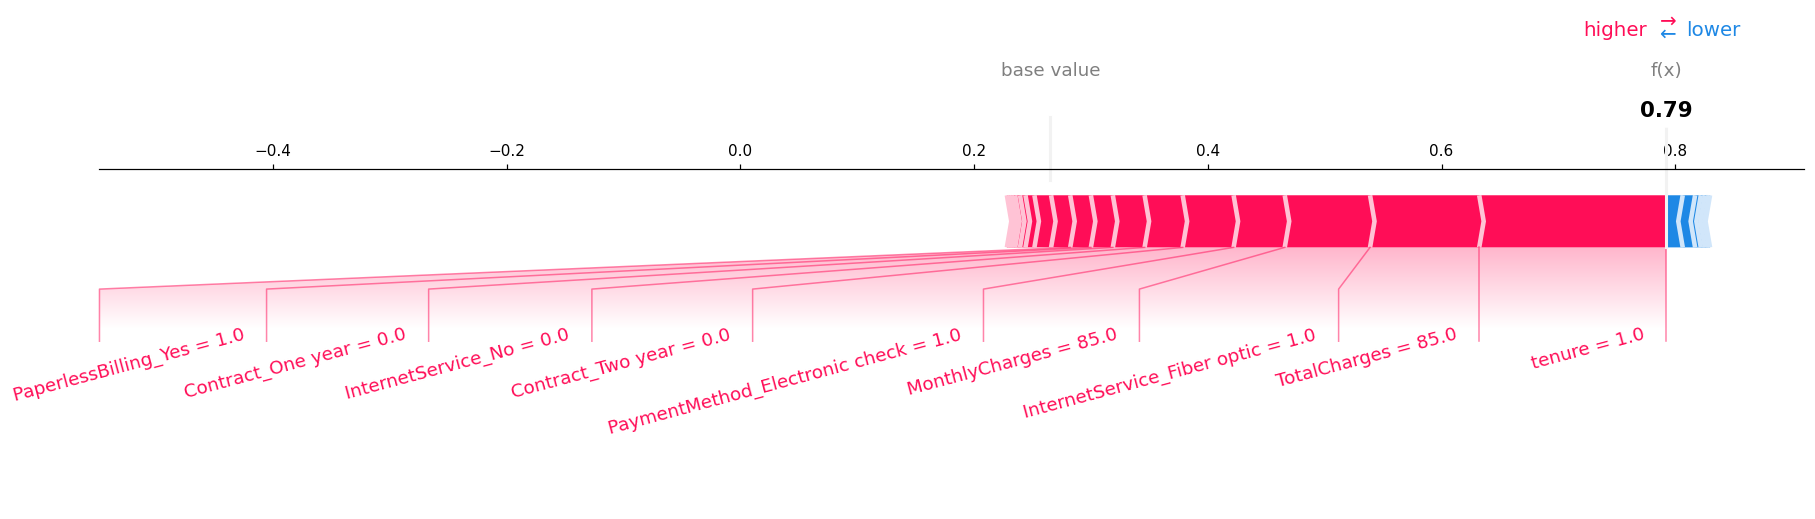

In [ ]:
# contribution_threshold menyembunyikan label faktor kecil supaya tulisan tidak bertumpuk
shap.plots.force(sv[idx_bima], matplotlib=True, figsize=(20, 4),
                 contribution_threshold=0.04, text_rotation=15)

# shap.initjs()
# shap.plots.force(sv[idx_sari])

**insight**

- Segmen paling lebar adalah tenure = 1.0, jadi ini faktor terbesar yang mendorong risiko naik. Ini sama dengan waterfall plot (sumbangan sekitar +0,16).
- Berikutnya TotalCharges = 85.0, InternetService_Fiber optic = 1.0, MonthlyCharges = 85.0, dan PaymentMethod_Electronic check = 1.0.
- Karena hampir semuanya merah, pelanggan ini naik dari 27% menjadi 79%.

Waterfall plot berisi informasi yang sama, tetapi disusun dari atas ke bawah sehingga lebih mudah dibaca stakeholder.

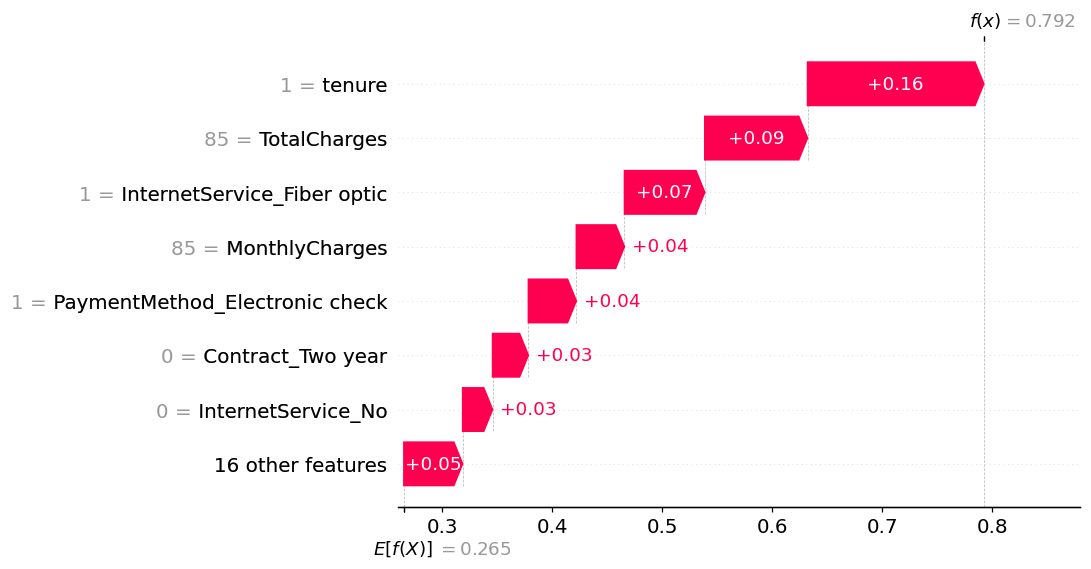

In [ ]:
# Waterfall: isinya sama dengan force plot, tapi disusun dari atas ke bawah sehingga lebih mudah dibaca
shap.plots.waterfall(sv[idx_bima], max_display=8)

### 3.5 Bandingkan LIME vs SHAP: apakah keduanya konsisten?

In [ ]:
# Bandingkan 5 faktor teratas LIME vs SHAP untuk pelanggan yang sama
# as_map()[1] = daftar (nomor fitur, bobot) untuk kelas 1 (Churn)
lime_map = penjelasan.as_map()[1]
lime_top = [FITUR[i] for i, _ in sorted(lime_map, key=lambda t: abs(t[1]), reverse=True)[:5]]

# Urutkan SHAP berdasarkan besar pengaruh (nilai mutlak)
shap_urut = pd.Series(sv.values[idx_bima], index=FITUR)
shap_top = list(shap_urut.abs().sort_values(ascending=False).head(5).index)

pd.DataFrame({"Top 5 LIME": lime_top, "Top 5 SHAP": shap_top}, index=[1, 2, 3, 4, 5])

,Top 5 LIME,Top 5 SHAP
1,tenure,tenure
2,InternetService_Fiber optic,TotalCharges
3,Contract_Two year,InternetService_Fiber optic
4,InternetService_No,MonthlyCharges
5,TotalCharges,PaymentMethod_Electronic check


In [ ]:
# Hitung berapa faktor yang sama muncul di kedua metode
sama = set(lime_top) & set(shap_top)
print(f"Faktor yang muncul di KEDUA metode ({len(sama)} dari 5): {sorted(sama)}")

# Cek arahnya juga: apakah LIME dan SHAP sepakat naik atau turun?
lime_arah = {FITUR[i]: b for i, b in lime_map}
for f in sorted(sama):
    a_lime = "naik" if lime_arah[f] > 0 else "turun"
    a_shap = "naik" if shap_urut[f] > 0 else "turun"
    print(f"  {f:35s} LIME: {a_lime:5s} | SHAP: {a_shap:5s} | {'sepakat' if a_lime == a_shap else 'BEDA'}")

Faktor yang muncul di KEDUA metode (3 dari 5): ['InternetService_Fiber optic', 'TotalCharges', 'tenure']
  InternetService_Fiber optic         LIME: naik  | SHAP: naik  | sepakat
  TotalCharges                        LIME: naik  | SHAP: naik  | sepakat
  tenure                              LIME: naik  | SHAP: naik  | sepakat


### 3.6 SHAP summary plot (beeswarm): pola keseluruhan dataset
* 1 titik = 1 pelanggan
* Urutan atas = faktor paling penting
* Kanan = menaikkan risiko churn, kiri = menurunkan
* Warna: merah = nilai fitur tinggi, biru = nilai fitur rendah

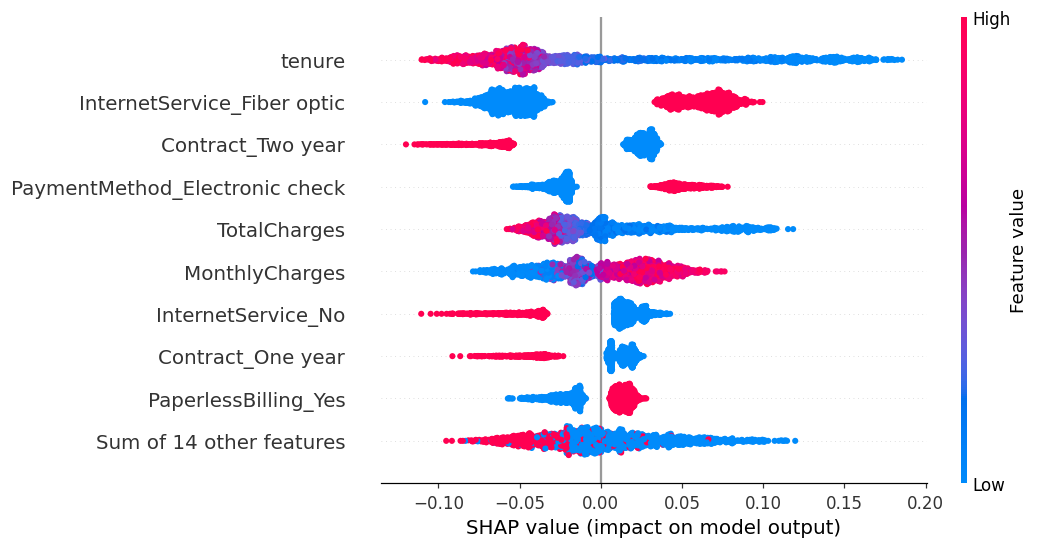

In [ ]:
# Beeswarm: 1 titik = 1 pelanggan, urutan atas = paling penting
# Kanan = menaikkan risiko churn, kiri = menurunkan. Merah = nilai fitur tinggi, biru = rendah
shap.plots.beeswarm(sv, max_display=10)

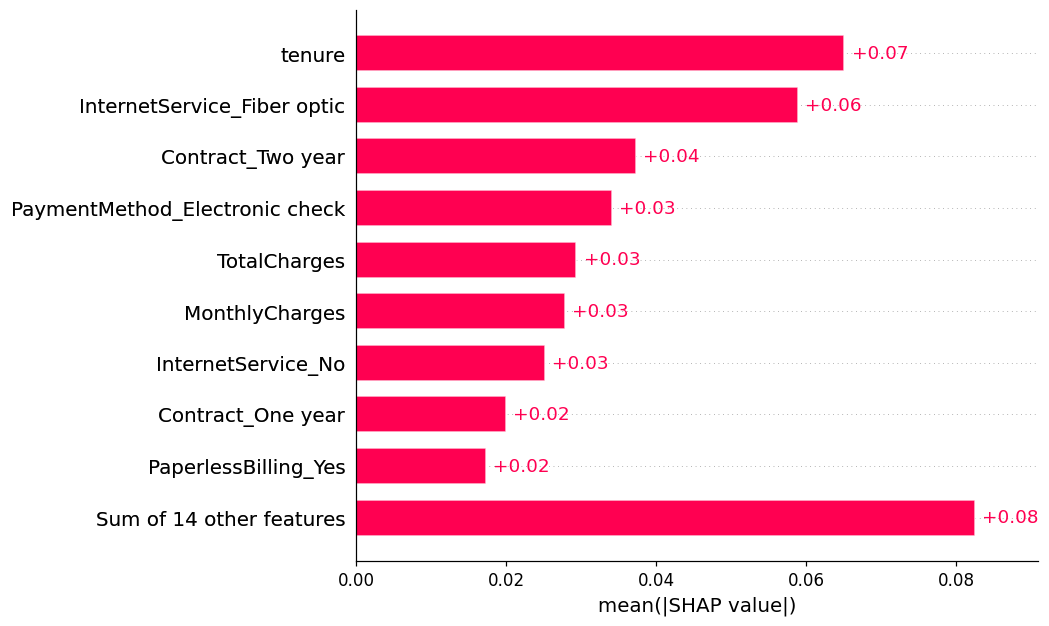

In [ ]:
# Versi sederhana: rata rata besar pengaruh tiap fitur (tanpa arah)
shap.plots.bar(sv, max_display=10)

### 3.7 SHAP dependence plot


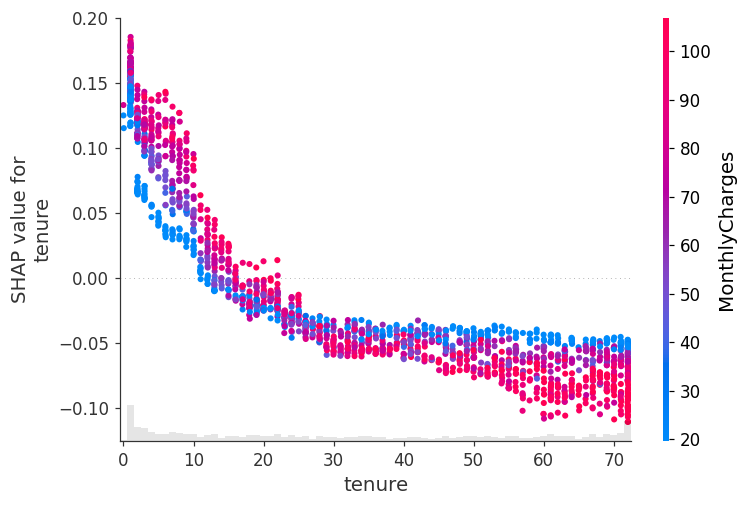

In [ ]:
# Dependence plot: sumbu X = nilai tenure, sumbu Y = SHAP tenure, warna = fitur lain yang berinteraksi
shap.plots.scatter(sv[:, "tenure"], color=sv[:, "MonthlyCharges"])

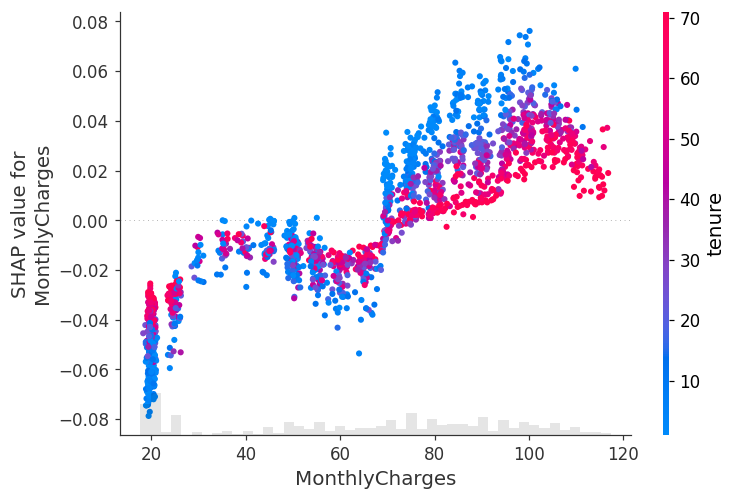

In [ ]:
# Dependence plot kedua: efek MonthlyCharges, diwarnai dengan tenure
shap.plots.scatter(sv[:, "MonthlyCharges"], color=sv[:, "tenure"])

In [ ]:
# Ringkasan arah pengaruh global: korelasi antara nilai fitur dan SHAP nya
ringkas = pd.DataFrame({
    "rata rata |SHAP|": np.abs(sv.values).mean(axis=0),
    "korelasi nilai fitur vs SHAP": [np.corrcoef(X_test[f], sv.values[:, i])[0, 1] for i, f in enumerate(FITUR)],
}, index=FITUR).sort_values("rata rata |SHAP|", ascending=False).head(8).round(3)

ringkas["arah menurut SHAP"] = np.where(ringkas["korelasi nilai fitur vs SHAP"] > 0,
                                        "makin tinggi, churn naik", "makin tinggi, churn turun")
ringkas

,rata rata |SHAP|,korelasi nilai fitur vs SHAP,arah menurut SHAP
tenure,0.065,-0.852,"makin tinggi, churn turun"
InternetService_Fiber optic,0.059,0.975,"makin tinggi, churn naik"
Contract_Two year,0.037,-0.980,"makin tinggi, churn turun"
PaymentMethod_Electronic check,0.034,0.976,"makin tinggi, churn naik"
TotalCharges,0.029,-0.747,"makin tinggi, churn turun"
MonthlyCharges,0.028,0.897,"makin tinggi, churn naik"
InternetService_No,0.025,-0.946,"makin tinggi, churn turun"
Contract_One year,0.020,-0.950,"makin tinggi, churn turun"


### Insight Kasus 3
**Penjelasan untuk Contoh pelanggan (peluang churn 79%, rata rata semua pelanggan 26%):**
* Kedua metode sepakat bahwa alasan utamanya adalah **`tenure` yang sangat pendek** (baru 1 bulan), **memakai internet fiber optic**, dan **`TotalCharges` kecil** (pelanggan baru, belum terikat). Kontrak bulanan dan pembayaran electronic check ikut menaikkan risiko.
* Pada SHAP, jumlah semua sumbangan ditambah base value **sama persis dengan prediksi model (79%)**, jadi penjelasannya lengkap dan tidak ada yang "hilang".

**Apakah LIME dan SHAP konsisten?**
* **Ya secara garis besar:** 3 dari 5 faktor teratas sama (`tenure`, `InternetService_Fiber optic`, `TotalCharges`) dan arahnya juga sama (semuanya menaikkan risiko).
*  LIME memunculkan `Contract_Two year=0` dan `InternetService_No=0`, sedangkan SHAP menaruh `MonthlyCharges` dan `PaymentMethod_Electronic check` di 5 besar. Perbedaan ini dikarenakan LIME memakai pendekatan linear lokal dari data tiruan acak, SHAP membagi kontribusi secara adil berdasarkan teori permainan. Di 3 seed yang dicoba, 3 alasan teratas LIME tetap sama, jadi untuk kasus ini LIME cukup stabil sehingga kedua metode **Tidak identik**.

**Pola global dari SHAP summary plot:**
* Fitur yang paling berpengaruh: `tenure`, `InternetService_Fiber optic`, `Contract_Two year`, `PaymentMethod_Electronic check`.
* Arah pengaruh: tenure panjang, kontrak 2 tahun, dan tidak berlangganan internet menurunkan churn. Fiber optic, electronic check, dan tagihan bulanan tinggi menaikkan churn.
* Dependence plot `tenure` menunjukkan sumbangan SHAP positif (menaikkan risiko) di tenure pendek, melewati nol di sekitar bulan ke 20, lalu menjadi negatif (menurunkan risiko) untuk tenure panjang. Ini sejalan dengan bentuk PDP di Kasus 2.



## Kasus 4: Komunikasi Insight ke Stakeholder Non Teknis


In [ ]:
# Bahan rekomendasi: churn rate asli berdasarkan jenis kontrak (dari data mentah, bukan dari model)
df_asli = pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_asli["Churn_angka"] = df_asli["Churn"].map({"Yes": 1, "No": 0})

churn_kontrak = (df_asli.groupby("Contract")["Churn_angka"].mean() * 100).round(1)
print("Churn rate per jenis kontrak (%):")
print(churn_kontrak)

# Churn rate pelanggan baru (tenure 12 bulan atau kurang) vs pelanggan lama
baru = df_asli[df_asli["tenure"] <= 12]["Churn_angka"].mean() * 100
lama = df_asli[df_asli["tenure"] > 12]["Churn_angka"].mean() * 100
print(f"\nChurn rate tenure 12 bulan atau kurang: {baru:.1f}%")
print(f"Churn rate tenure di atas 12 bulan     : {lama:.1f}%")

Churn rate per jenis kontrak (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn_angka, dtype: float64

Churn rate tenure 12 bulan atau kurang: 47.4%
Churn rate tenure di atas 12 bulan     : 17.1%


Mengubah nilai SHAP menjadi kalimat yang bisa langsung dibaca tim retensi atau customer service.

In [ ]:
# Kamus: nama kolom menjadi kalimat yang dimengerti orang awam
def deskripsi(fitur, nilai):
    kamus = {
        "tenure":                       f"baru berlangganan {int(nilai)} bulan",
        "MonthlyCharges":               f"tagihan bulanan ${nilai:.0f}",
        "TotalCharges":                 f"total pembayaran selama ini ${nilai:.0f}",
        "Contract_One year":            "memakai kontrak 1 tahun" if nilai == 1 else "tidak memakai kontrak 1 tahun",
        "Contract_Two year":            "memakai kontrak 2 tahun" if nilai == 1 else "tidak memakai kontrak 2 tahun",
        "InternetService_Fiber optic":  "memakai internet fiber optic" if nilai == 1 else "tidak memakai fiber optic",
        "PaymentMethod_Electronic check": "membayar dengan electronic check" if nilai == 1 else "tidak membayar dengan electronic check",
        "OnlineSecurity_Yes":           "memakai layanan keamanan online" if nilai == 1 else "belum memakai layanan keamanan online",
        "TechSupport_Yes":              "memakai layanan tech support" if nilai == 1 else "belum memakai tech support",
        "PaperlessBilling_Yes":         "memakai tagihan tanpa kertas" if nilai == 1 else "memakai tagihan kertas",
    }
    return kamus.get(fitur, f"{fitur} = {nilai:.0f}")


def jelaskan_ke_bisnis(posisi, nama="Pelanggan ini", top=3):
    nilai_shap = pd.Series(sv.values[posisi], index=FITUR)    # SHAP pelanggan ini
    data = X_test.iloc[posisi]                                # data pelanggan ini
    p_rata = peluang_test.mean()
    p_orang = peluang_test[posisi]

    # Ambil faktor yang pengaruhnya cukup besar saja (di atas 2 poin persen)
    penaik = nilai_shap[nilai_shap > 0.02].sort_values(ascending=False).head(top)
    penahan = nilai_shap[nilai_shap < -0.02].sort_values().head(2)

    print(f" APA     : Rata rata pelanggan punya peluang churn {p_rata:.0%}. {nama} {p_orang:.0%}.")
    if len(penaik):
        print(" KENAPA  : Penyebab utamanya: " + ", ".join(deskripsi(f, data[f]) for f in penaik.index) + ".")
    if len(penahan):
        print(" PENAHAN : Risikonya tertahan karena " + " dan ".join(deskripsi(f, data[f]) for f in penahan.index) + ".")
    if p_orang >= 0.6:
        aksi = "hubungi dalam 7 hari, tawarkan diskon upgrade ke kontrak 1 tahun."
    elif p_orang >= 0.4:
        aksi = "masukkan ke daftar pantau dan kirim penawaran paket yang sesuai."
    else:
        aksi = "risiko rendah, tidak perlu tindakan khusus."
    print(f" AKSI    : {aksi}")


jelaskan_ke_bisnis(idx_bima, nama="Bima")

 APA     : Rata rata pelanggan punya peluang churn 26%. Bima 79%.
 KENAPA  : Penyebab utamanya: baru berlangganan 1 bulan, total pembayaran selama ini $85, memakai internet fiber optic.
 AKSI    : hubungi dalam 7 hari, tawarkan diskon upgrade ke kontrak 1 tahun.


### Ringkasan Eksekutif untuk Tim Manajemen (maksimal setengah halaman)

**Tujuan.** Model memperkirakan pelanggan yang berisiko berhenti berlangganan (churn). Saat ini 1 dari 4 pelanggan (26,5%) churn. Model benar menebak sekitar 80% kasus, jadi cocok untuk menentukan siapa yang dihubungi lebih dulu, bukan untuk memastikan satu orang pasti churn.

**Apa yang paling memengaruhi churn?**
1. **Masa awal berlangganan.** Pelanggan dengan masa berlangganan 12 bulan atau kurang churn 47%, yang lebih lama hanya 17%.
2. **Jenis kontrak.** Kontrak bulanan churn 42,7%, kontrak 1 tahun 11,3%, kontrak 2 tahun hanya 2,8%.
3. **Fiber optic dan electronic check.** Keduanya ikut menaikkan risiko churn.

**Contoh.** Bima punya peluang churn 79%, jauh di atas rata rata 26%, karena baru berlangganan 1 bulan, memakai fiber optic, dan berkontrak bulanan.

**Rekomendasi:**
* **Program 90 hari pertama** untuk pelanggan baru (sapaan onboarding, cek kualitas koneksi, tindak lanjut), karena tahun pertama paling rawan.
* **Tawarkan diskon atau upgrade** agar pelanggan bulanan berisiko tinggi pindah ke kontrak 1 atau 2 tahun, dan hubungi mereka dalam 7 hari.
* **Tinjau harga dan kualitas layanan fiber optic.**

**Model** menunjukkan pola, bukan sebab akibat. Uji dulu dengan A/B test sebelum diluncurkan penuh.

In [ ]:
# Ukur waktu komputasi untuk 1 pelanggan
t0 = time.perf_counter()
explainer_lime.explain_instance(bima.values, fungsi_prediksi, num_features=8)
waktu_lime = time.perf_counter() - t0

t0 = time.perf_counter()
explainer_shap(X_test.iloc[[idx_bima]])
waktu_shap_1 = time.perf_counter() - t0

# SHAP untuk seluruh data uji sekaligus
t0 = time.perf_counter()
explainer_shap(X_test)
waktu_shap_semua = time.perf_counter() - t0

print(f"LIME, 1 pelanggan              : {waktu_lime:.2f} detik")
print(f"SHAP (Tree), 1 pelanggan       : {waktu_shap_1:.3f} detik")
print(f"SHAP (Tree), {len(X_test)} pelanggan : {waktu_shap_semua:.2f} detik")
print(f"Perkiraan LIME untuk {len(X_test)} pelanggan : {waktu_lime * len(X_test) / 60:.1f} menit")

LIME, 1 pelanggan              : 0.44 detik
SHAP (Tree), 1 pelanggan       : 0.077 detik
SHAP (Tree), 1761 pelanggan : 37.32 detik
Perkiraan LIME untuk 1761 pelanggan : 13.0 menit


## Reflection Questions

### 7. Dalam kasus apa kamu akan lebih memilih menggunakan LIME dibandingkan SHAP, atau sebaliknya? Jelaskan pertimbangan dari sisi kecepatan komputasi, konsistensi hasil, dan kebutuhan interpretasi (lokal vs global).

**Kecepatan komputasi.**  **SHAP (TreeExplainer) sangat cepat**, sekitar 0,08 detik per pelanggan, karena memanfaatkan struktur pohon. LIME butuh membuat ribuan data tiruan dan meminta model menebak semuanya, sekitar 0,44 detik per pelanggan(sekitar 13 menit untuk 1.761 pelanggan vs 37 detik untuk SHAP.), dan kalau dijalankan untuk ribuan pelanggan bisa memakan waktu beberapa menit. Angka pastinya tergantung komputer. Untuk model non pohon (neural network, SVM), SHAP generik (KernelExplainer) bisa sangat lambat, dan di situ LIME bisa lebih praktis.

**Konsistensi hasil.** SHAP punya dasar teori (nilai Shapley) dan memenuhi sifat penjumlahan: base value ditambah semua SHAP selalu sama dengan prediksi. Hasilnya **deterministik** untuk TreeExplainer. LIME memakai sampel acak sehingga hasilnya bisa sedikit berubah antar seed, dan penjelasannya bergantung pada pilihan lingkungan sekitar dan jumlah fitur. Kalau keputusan perlu bisa diaudit dan diulang dengan hasil sama, SHAP lebih aman.

**Kebutuhan interpretasi (lokal vs global).** SHAP bisa dipakai untuk **keduanya**: satu pelanggan (waterfall, force) dan seluruh data (beeswarm, bar, dependence) karena dihitung dari nilai lokal yang sama. LIME **hanya lokal**, yaitu satu prediksi per satu penjelasan.

**Kesimpulan saya:**
* Pilih **SHAP** kalau modelnya berbasis pohon, butuh gambaran global dan lokal, atau butuh hasil yang konsisten dan bisa dipakai.
* Pilih **LIME** kalau modelnya bukan pohon dan harus memakai KernelExplainer yang lambat, kalau butuh penjelasan cepat dan sederhana untuk satu kasus, atau kalau datanya berupa teks atau gambar yang sudah punya dukungan LIME yang matang. Idealnya LIME dicek stabilitasnya dulu, atau dibandingkan dengan SHAP.

### 8. Bagaimana kamu memastikan insight dari SHAP/LIME yang kamu sajikan tidak disalahartikan oleh stakeholder non-teknis (misalnya menganggap korelasi sebagai kausalitas)? Jelaskan strategi komunikasimu.

Strategi yang saya pakai:
1. **Pakai bahasa "model melihat" bukan "menyebabkan".** Tulis *"Pelanggan kontrak bulanan lebih sering diprediksi churn"* dan bukan *"Kontrak bulanan menyebabkan churn"*. SHAP dan LIME menjelaskan cara model berpikir, bukan cara dunia bekerja.
2. **Sampaikan batasan di awal.** Cantumkan satu kalimat tetap di setiap laporan: "Ini adalah pola dari data historis, bukan bukti sebab akibat."
3. **Beri contoh yang konkret.** Misalnya pelanggan fiber optic memang lebih sering churn, tetapi bisa jadi penyebabnya harga atau gangguan jaringan di area tertentu, bukan fiber optic itu sendiri. Pelanggan baru dan kontrak bulanan juga saling berkaitan.
4. **Validasi dengan eksperimen sebelum bertindak besar.** Rekomendasi seperti diskon kontrak tahunan diuji dengan **A/B test** atau pilot kecil. Hasil eksperimen bisa membuktikan sebab akibat, sedangkan SHAP tidak.
5. **Libatkan pakar bisnis.** Minta tim retensi dan customer service menilai apakah penjelasan model masuk akal, dan cari penjelasan alternatif (variabel yang tidak tercatat di data).
6. **Sederhanakan visual.** Tampilkan waterfall plot dan tiga alasan teratas, simpan beeswarm untuk tim teknis. Hindari istilah log odds, base value, dan sejenisnya.
7. **Pisahkan prediksi dari tindakan.** Model mengatakan *siapa* yang berisiko. Keputusan *apa* yang harus dilakukan datang dari pengujian dan pertimbangan bisnis.
